# 04 -- Model Training

**Project:** Predictive Analytics for Enterprise Streaming Acquisitions  
**Course:** CMPS 451 -- Data Mining, Big Data & Analytics (Spring 2026)  
**Team:** 11

---

## Objectives
1. Build regression models (Linear, Decision Tree, Random Forest, GBT) to predict `averageRating`
2. Build classification models (Logistic, Decision Tree, Random Forest) to predict rating tier
3. Apply K-Means clustering for title segmentation
4. Perform hyperparameter tuning with CrossValidator
5. Save all trained models

In [1]:
# ── Imports & Environment Setup ──
import os
import sys
import findspark

os.environ['HADOOP_HOME'] = r'A:\hadoop'
os.environ['SPARK_HOME'] = r'A:\spark'
os.environ['PATH'] = r'A:\hadoop\bin;' + os.environ.get('PATH', '')
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

findspark.init()
# ── Imports ──
import os
import json
import numpy as np
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import (
    LinearRegression, DecisionTreeRegressor,
    RandomForestRegressor, GBTRegressor
)
from pyspark.ml.classification import (
    LogisticRegression, DecisionTreeClassifier,
    RandomForestClassifier
)
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import (
    RegressionEvaluator, MulticlassClassificationEvaluator,
    ClusteringEvaluator
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline

OUTPUT_DIR = os.path.join("outputs")
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)


spark = (
    SparkSession.builder
    .appName("IMDb_Modeling")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} ready.")

Spark 3.5.1 ready.


In [2]:
# ── Load feature matrix ──
df = spark.read.parquet(os.path.join(OUTPUT_DIR, "parquet", "features"))

with open(os.path.join(OUTPUT_DIR, "feature_columns.json")) as f:
    feat_meta = json.load(f)

feature_cols = feat_meta['all_feature_cols']
print(f"Loaded {df.count():,} rows with {len(feature_cols)} features")

# Drop rows with any null in feature columns
df = df.dropna(subset=feature_cols + ['averageRating', 'ratingTier'])
print(f"After dropping nulls: {df.count():,} rows")

Loaded 186,201 rows with 52 features
After dropping nulls: 186,201 rows


In [3]:
# ── Assemble feature vector ──
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw", handleInvalid="skip")
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)

pipeline = Pipeline(stages=[assembler, scaler])
pipeline_model = pipeline.fit(df)
df_ml = pipeline_model.transform(df)

# Rename targets
df_ml = df_ml.withColumnRenamed("averageRating", "label_reg")
df_ml = df_ml.withColumnRenamed("ratingTier", "label_cls")

print(f"Feature vector assembled: {len(feature_cols)} features")
df_ml.select("features", "label_reg", "label_cls").show(3, truncate=50)

Feature vector assembled: 52 features
+--------------------------------------------------+---------+---------+
|                                          features|label_reg|label_cls|
+--------------------------------------------------+---------+---------+
|[-0.006812919582466372,-3.792838689490371,-3.68...|      6.9|        1|
|[-6.195643965026272E-4,-3.792838689490371,-3.68...|      6.1|        1|
|[-0.004008381385048827,-3.7496317386937164,-3.6...|      6.4|        1|
+--------------------------------------------------+---------+---------+
only showing top 3 rows



In [4]:
# ── Train / Validation / Test Split (70/15/15) ──
train_df, val_df, test_df = df_ml.randomSplit([0.70, 0.15, 0.15], seed=42)

train_df.cache()
val_df.cache()
test_df.cache()

print(f"Train: {train_df.count():,}")
print(f"Validation: {val_df.count():,}")
print(f"Test: {test_df.count():,}")

Train: 130,643
Validation: 27,939
Test: 27,619


## 1. Regression Models (Predict `averageRating`)

In [5]:
# ── Helper function ──
reg_evaluator_rmse = RegressionEvaluator(labelCol="label_reg", metricName="rmse")
reg_evaluator_mae = RegressionEvaluator(labelCol="label_reg", metricName="mae")
reg_evaluator_r2 = RegressionEvaluator(labelCol="label_reg", metricName="r2")

regression_results = []

def eval_regression(model_name, model, train, val, test):
    results = {"model": model_name}
    for split_name, data in [("train", train), ("val", val), ("test", test)]:
        preds = model.transform(data)
        rmse = reg_evaluator_rmse.evaluate(preds)
        mae = reg_evaluator_mae.evaluate(preds)
        r2 = reg_evaluator_r2.evaluate(preds)
        results[f"{split_name}_rmse"] = round(rmse, 4)
        results[f"{split_name}_mae"] = round(mae, 4)
        results[f"{split_name}_r2"] = round(r2, 4)
    regression_results.append(results)
    print(f"\n{model_name}:")
    print(f"  Train  -- RMSE: {results['train_rmse']:.4f}, MAE: {results['train_mae']:.4f}, R²: {results['train_r2']:.4f}")
    print(f"  Val    -- RMSE: {results['val_rmse']:.4f}, MAE: {results['val_mae']:.4f}, R²: {results['val_r2']:.4f}")
    print(f"  Test   -- RMSE: {results['test_rmse']:.4f}, MAE: {results['test_mae']:.4f}, R²: {results['test_r2']:.4f}")
    return results

In [6]:
# ── 1a: Linear Regression ──
print("Training Linear Regression...")
lr = LinearRegression(featuresCol="features", labelCol="label_reg", maxIter=100)
lr_model = lr.fit(train_df)
eval_regression("Linear Regression", lr_model, train_df, val_df, test_df)

lr_model.write().overwrite().save(os.path.join(MODELS_DIR, "linear_regression"))
print("Model saved.")

Training Linear Regression...

Linear Regression:
  Train  -- RMSE: 0.5917, MAE: 0.4366, R²: 0.7921
  Val    -- RMSE: 0.5926, MAE: 0.4361, R²: 0.7907
  Test   -- RMSE: 0.5937, MAE: 0.4376, R²: 0.7932
Model saved.


In [7]:
# ── 1b: Decision Tree Regressor ──
print("Training Decision Tree Regressor...")
dt_reg = DecisionTreeRegressor(featuresCol="features", labelCol="label_reg", maxDepth=10)
dt_reg_model = dt_reg.fit(train_df)
eval_regression("Decision Tree Regressor", dt_reg_model, train_df, val_df, test_df)

dt_reg_model.write().overwrite().save(os.path.join(MODELS_DIR, "dt_regressor"))
print("Model saved.")

Training Decision Tree Regressor...

Decision Tree Regressor:
  Train  -- RMSE: 0.5298, MAE: 0.3754, R²: 0.8333
  Val    -- RMSE: 0.5542, MAE: 0.3912, R²: 0.8169
  Test   -- RMSE: 0.5577, MAE: 0.3922, R²: 0.8174
Model saved.


In [8]:
# ── 1c: Random Forest Regressor (with CV tuning) ──
print("Training Random Forest Regressor with CrossValidator...")
rf_reg = RandomForestRegressor(featuresCol="features", labelCol="label_reg", seed=42)

paramGrid_rf = (
    ParamGridBuilder()
    .addGrid(rf_reg.numTrees, [50, 100])
    .addGrid(rf_reg.maxDepth, [8, 12])
    .build()
)

cv_rf = CrossValidator(
    estimator=rf_reg,
    estimatorParamMaps=paramGrid_rf,
    evaluator=reg_evaluator_rmse,
    numFolds=3,
    seed=42
)

cv_rf_model = cv_rf.fit(train_df)
rf_best = cv_rf_model.bestModel

print(f"Best RF: numTrees={rf_best.getNumTrees}, maxDepth={rf_best._java_obj.getMaxDepth()}")
eval_regression("Random Forest Regressor", rf_best, train_df, val_df, test_df)

rf_best.write().overwrite().save(os.path.join(MODELS_DIR, "rf_regressor"))
print("Model saved.")

Training Random Forest Regressor with CrossValidator...
Best RF: numTrees=100, maxDepth=12

Random Forest Regressor:
  Train  -- RMSE: 0.4714, MAE: 0.3358, R²: 0.8680
  Val    -- RMSE: 0.5124, MAE: 0.3605, R²: 0.8435
  Test   -- RMSE: 0.5171, MAE: 0.3638, R²: 0.8431
Model saved.


In [9]:
# ── 1d: Gradient Boosted Trees Regressor ──
print("Training GBT Regressor...")
gbt_reg = GBTRegressor(featuresCol="features", labelCol="label_reg",
                        maxIter=50, maxDepth=8, seed=42)
gbt_model = gbt_reg.fit(train_df)
eval_regression("GBT Regressor", gbt_model, train_df, val_df, test_df)

gbt_model.write().overwrite().save(os.path.join(MODELS_DIR, "gbt_regressor"))
print("Model saved.")

Training GBT Regressor...

GBT Regressor:
  Train  -- RMSE: 0.4557, MAE: 0.3291, R²: 0.8767
  Val    -- RMSE: 0.5069, MAE: 0.3592, R²: 0.8468
  Test   -- RMSE: 0.5145, MAE: 0.3639, R²: 0.8446
Model saved.


In [10]:
# ── Regression Summary ──
import pandas as pd
reg_df = pd.DataFrame(regression_results)
print("\n" + "="*80)
print("REGRESSION RESULTS SUMMARY")
print("="*80)
print(reg_df.to_string(index=False))
reg_df.to_csv(os.path.join(RESULTS_DIR, "regression_results.csv"), index=False)


REGRESSION RESULTS SUMMARY
                  model  train_rmse  train_mae  train_r2  val_rmse  val_mae  val_r2  test_rmse  test_mae  test_r2
      Linear Regression      0.5917     0.4366    0.7921    0.5926   0.4361  0.7907     0.5937    0.4376   0.7932
Decision Tree Regressor      0.5298     0.3754    0.8333    0.5542   0.3912  0.8169     0.5577    0.3922   0.8174
Random Forest Regressor      0.4714     0.3358    0.8680    0.5124   0.3605  0.8435     0.5171    0.3638   0.8431
          GBT Regressor      0.4557     0.3291    0.8767    0.5069   0.3592  0.8468     0.5145    0.3639   0.8446


## 2. Classification Models (Predict Rating Tier)

In [11]:
# ── Helper function ──
cls_evaluator_acc = MulticlassClassificationEvaluator(labelCol="label_cls", metricName="accuracy")
cls_evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label_cls", metricName="f1")
cls_evaluator_precision = MulticlassClassificationEvaluator(labelCol="label_cls", metricName="weightedPrecision")
cls_evaluator_recall = MulticlassClassificationEvaluator(labelCol="label_cls", metricName="weightedRecall")

classification_results = []

def eval_classification(model_name, model, train, val, test):
    results = {"model": model_name}
    for split_name, data in [("train", train), ("val", val), ("test", test)]:
        preds = model.transform(data)
        acc = cls_evaluator_acc.evaluate(preds)
        f1 = cls_evaluator_f1.evaluate(preds)
        prec = cls_evaluator_precision.evaluate(preds)
        rec = cls_evaluator_recall.evaluate(preds)
        results[f"{split_name}_accuracy"] = round(acc, 4)
        results[f"{split_name}_f1"] = round(f1, 4)
        results[f"{split_name}_precision"] = round(prec, 4)
        results[f"{split_name}_recall"] = round(rec, 4)
    classification_results.append(results)
    print(f"\n{model_name}:")
    print(f"  Train  -- Acc: {results['train_accuracy']:.4f}, F1: {results['train_f1']:.4f}")
    print(f"  Val    -- Acc: {results['val_accuracy']:.4f}, F1: {results['val_f1']:.4f}")
    print(f"  Test   -- Acc: {results['test_accuracy']:.4f}, F1: {results['test_f1']:.4f}")
    return results

In [12]:
# ── 2a: Logistic Regression ──
print("Training Logistic Regression (multiclass)...")
log_reg = LogisticRegression(featuresCol="features", labelCol="label_cls",
                              maxIter=100, family="multinomial")
log_reg_model = log_reg.fit(train_df)
eval_classification("Logistic Regression", log_reg_model, train_df, val_df, test_df)

log_reg_model.write().overwrite().save(os.path.join(MODELS_DIR, "logistic_regression"))
print("Model saved.")

Training Logistic Regression (multiclass)...

Logistic Regression:
  Train  -- Acc: 0.8071, F1: 0.8056
  Val    -- Acc: 0.8070, F1: 0.8055
  Test   -- Acc: 0.8066, F1: 0.8052
Model saved.


In [13]:
# ── 2b: Decision Tree Classifier ──
print("Training Decision Tree Classifier...")
dt_cls = DecisionTreeClassifier(featuresCol="features", labelCol="label_cls", maxDepth=10)
dt_cls_model = dt_cls.fit(train_df)
eval_classification("Decision Tree Classifier", dt_cls_model, train_df, val_df, test_df)

dt_cls_model.write().overwrite().save(os.path.join(MODELS_DIR, "dt_classifier"))
print("Model saved.")

Training Decision Tree Classifier...

Decision Tree Classifier:
  Train  -- Acc: 0.8391, F1: 0.8373
  Val    -- Acc: 0.8316, F1: 0.8298
  Test   -- Acc: 0.8309, F1: 0.8290
Model saved.


In [14]:
# ── 2c: Random Forest Classifier (with CV tuning) ──
print("Training Random Forest Classifier with CrossValidator...")
rf_cls = RandomForestClassifier(featuresCol="features", labelCol="label_cls", seed=42)

paramGrid_rf_cls = (
    ParamGridBuilder()
    .addGrid(rf_cls.numTrees, [50, 100])
    .addGrid(rf_cls.maxDepth, [8, 12])
    .build()
)

cv_rf_cls = CrossValidator(
    estimator=rf_cls,
    estimatorParamMaps=paramGrid_rf_cls,
    evaluator=cls_evaluator_f1,
    numFolds=3,
    seed=42
)

cv_rf_cls_model = cv_rf_cls.fit(train_df)
rf_cls_best = cv_rf_cls_model.bestModel

print(f"Best RF Classifier: numTrees={rf_cls_best.getNumTrees}, maxDepth={rf_cls_best._java_obj.getMaxDepth()}")
eval_classification("Random Forest Classifier", rf_cls_best, train_df, val_df, test_df)

rf_cls_best.write().overwrite().save(os.path.join(MODELS_DIR, "rf_classifier"))
print("Model saved.")

Training Random Forest Classifier with CrossValidator...
Best RF Classifier: numTrees=100, maxDepth=12

Random Forest Classifier:
  Train  -- Acc: 0.8604, F1: 0.8585
  Val    -- Acc: 0.8429, F1: 0.8409
  Test   -- Acc: 0.8406, F1: 0.8385
Model saved.


In [15]:
# ── Classification Summary ──
cls_df = pd.DataFrame(classification_results)
print("\n" + "="*80)
print("CLASSIFICATION RESULTS SUMMARY")
print("="*80)
print(cls_df.to_string(index=False))
cls_df.to_csv(os.path.join(RESULTS_DIR, "classification_results.csv"), index=False)


CLASSIFICATION RESULTS SUMMARY
                   model  train_accuracy  train_f1  train_precision  train_recall  val_accuracy  val_f1  val_precision  val_recall  test_accuracy  test_f1  test_precision  test_recall
     Logistic Regression          0.8071    0.8056           0.8079        0.8071        0.8070  0.8055         0.8081      0.8070         0.8066   0.8052          0.8076       0.8066
Decision Tree Classifier          0.8391    0.8373           0.8418        0.8391        0.8316  0.8298         0.8344      0.8316         0.8309   0.8290          0.8340       0.8309
Random Forest Classifier          0.8604    0.8585           0.8660        0.8604        0.8429  0.8409         0.8479      0.8429         0.8406   0.8385          0.8457       0.8406


## 3. K-Means Clustering (Title Segmentation)

In [16]:
# ── Elbow method to find optimal K ──
print("Running Elbow Method for K-Means...")
silhouette_evaluator = ClusteringEvaluator(featuresCol="features")

k_values = range(2, 11)
silhouette_scores = []
wcss_scores = []

for k in k_values:
    kmeans = KMeans(featuresCol="features", k=k, seed=42, maxIter=20)
    km_model = kmeans.fit(train_df)
    preds = km_model.transform(train_df)
    sil = silhouette_evaluator.evaluate(preds)
    wcss = km_model.summary.trainingCost
    silhouette_scores.append(sil)
    wcss_scores.append(wcss)
    print(f"  K={k}: Silhouette={sil:.4f}, WCSS={wcss:.0f}")

# Find best K by silhouette
best_k = list(k_values)[np.argmax(silhouette_scores)]
print(f"\nBest K by Silhouette: {best_k}")

Running Elbow Method for K-Means...
  K=2: Silhouette=0.3293, WCSS=6400242
  K=3: Silhouette=0.1446, WCSS=6216201
  K=4: Silhouette=0.0900, WCSS=6120049
  K=5: Silhouette=0.0879, WCSS=5717829
  K=6: Silhouette=0.0930, WCSS=5688007
  K=7: Silhouette=0.0852, WCSS=5471273
  K=8: Silhouette=0.0983, WCSS=5333437
  K=9: Silhouette=0.1163, WCSS=5211612
  K=10: Silhouette=0.0869, WCSS=5143501

Best K by Silhouette: 2


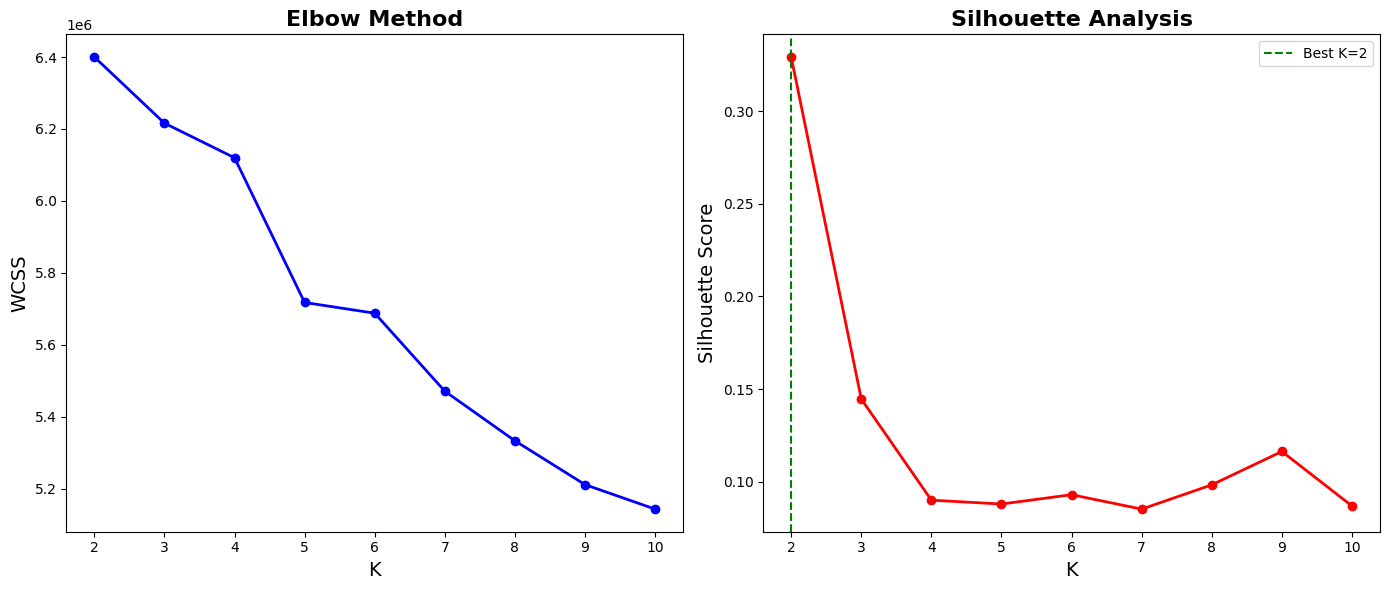

In [17]:
# ── Plot Elbow & Silhouette ──
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(list(k_values), wcss_scores, 'bo-', linewidth=2)
ax1.set_xlabel('K', fontsize=14)
ax1.set_ylabel('WCSS', fontsize=14)
ax1.set_title('Elbow Method', fontsize=16, fontweight='bold')

ax2.plot(list(k_values), silhouette_scores, 'ro-', linewidth=2)
ax2.axvline(best_k, color='green', linestyle='--', label=f'Best K={best_k}')
ax2.set_xlabel('K', fontsize=14)
ax2.set_ylabel('Silhouette Score', fontsize=14)
ax2.set_title('Silhouette Analysis', fontsize=16, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join('outputs', 'plots', '11_kmeans_elbow.png'))
plt.show()

In [18]:
# ── Train final K-Means with best K ──
print(f"Training final K-Means with K={best_k}...")
kmeans_final = KMeans(featuresCol="features", k=best_k, seed=42, maxIter=50)
kmeans_model = kmeans_final.fit(train_df)

# Analyze clusters
clustered = kmeans_model.transform(df_ml)

print("\nCluster Analysis:")
cluster_stats = (
    clustered.groupBy("prediction")
    .agg(
        F.count("*").alias("count"),
        F.round(F.mean("label_reg"), 2).alias("avg_rating"),
        F.round(F.stddev("label_reg"), 2).alias("std_rating"),
        F.round(F.mean("runtimeMinutes"), 0).alias("avg_runtime"),
        F.round(F.mean("startYear"), 0).alias("avg_year"),
        F.round(F.mean("logNumVotes"), 2).alias("avg_log_votes")
    )
    .orderBy("prediction")
)
cluster_stats.show()

kmeans_model.write().overwrite().save(os.path.join(MODELS_DIR, "kmeans"))
print("K-Means model saved.")

Training final K-Means with K=2...

Cluster Analysis:
+----------+------+----------+----------+-----------+--------+-------------+
|prediction| count|avg_rating|std_rating|avg_runtime|avg_year|avg_log_votes|
+----------+------+----------+----------+-----------+--------+-------------+
|         0|153739|      5.91|      1.25|      100.0|  1999.0|         6.58|
|         1| 32462|      6.94|      1.18|      172.0|  2008.0|         6.56|
+----------+------+----------+----------+-----------+--------+-------------+

K-Means model saved.


In [19]:
# ── Save clustering results ──
clustering_results = {
    "best_k": best_k,
    "silhouette_scores": {str(k): round(s, 4) for k, s in zip(k_values, silhouette_scores)},
    "wcss_scores": {str(k): round(w, 2) for k, w in zip(k_values, wcss_scores)}
}

with open(os.path.join(RESULTS_DIR, "clustering_results.json"), "w") as f:
    json.dump(clustering_results, f, indent=2)

print("All models trained and saved!")
print("\nProceed to 05_evaluation.ipynb")

All models trained and saved!

Proceed to 05_evaluation.ipynb


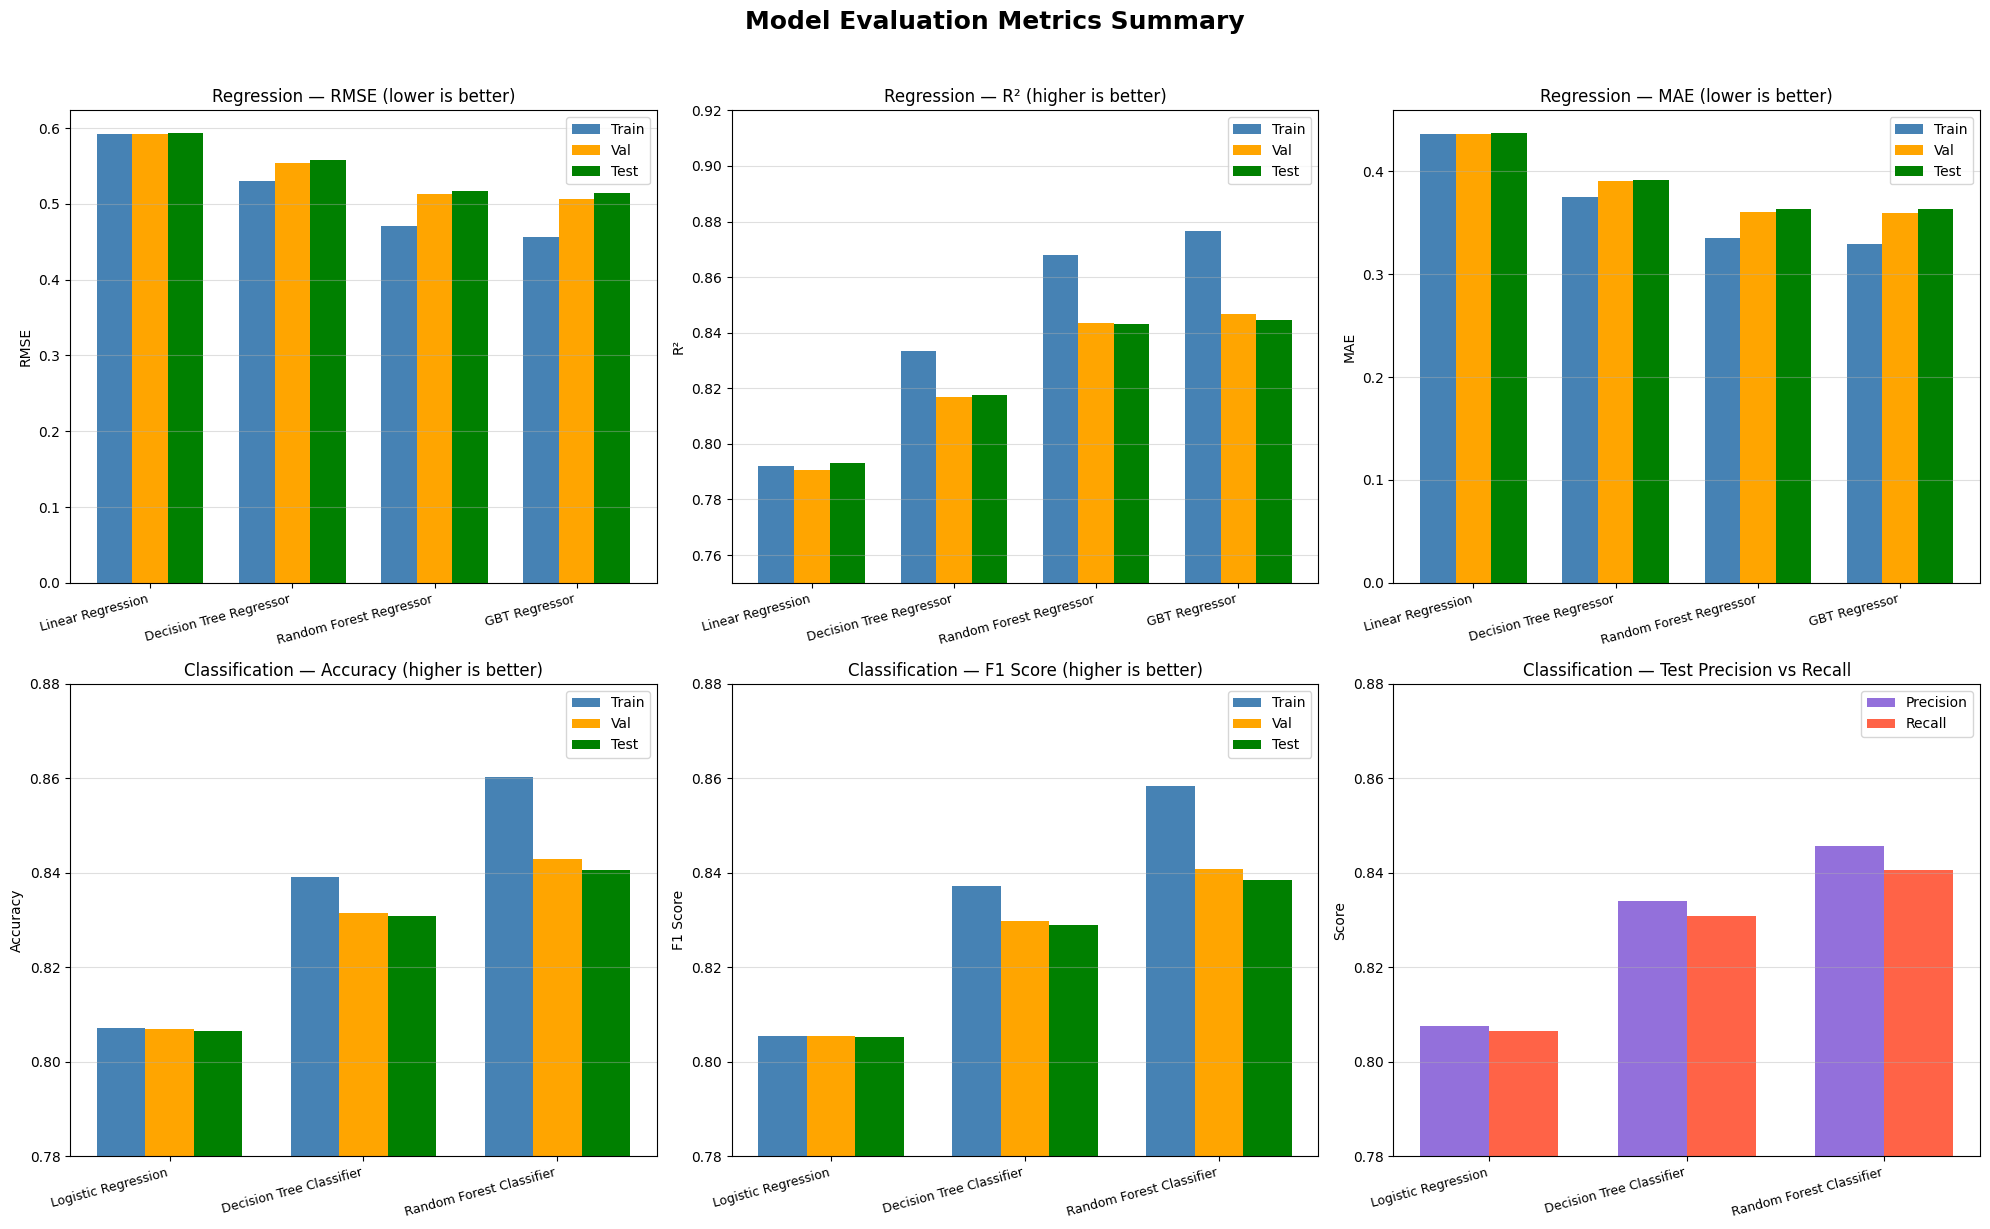


REGRESSION RESULTS SUMMARY
                  model  train_rmse  train_mae  train_r2  val_rmse  val_mae  val_r2  test_rmse  test_mae  test_r2
      Linear Regression      0.5917     0.4366    0.7921    0.5926   0.4361  0.7907     0.5937    0.4376   0.7932
Decision Tree Regressor      0.5298     0.3754    0.8333    0.5542   0.3912  0.8169     0.5577    0.3922   0.8174
Random Forest Regressor      0.4714     0.3358    0.8680    0.5124   0.3605  0.8435     0.5171    0.3638   0.8431
          GBT Regressor      0.4557     0.3291    0.8767    0.5069   0.3592  0.8468     0.5145    0.3639   0.8446

CLASSIFICATION RESULTS SUMMARY
                   model  train_accuracy  train_f1  train_precision  train_recall  val_accuracy  val_f1  val_precision  val_recall  test_accuracy  test_f1  test_precision  test_recall
     Logistic Regression          0.8071    0.8056           0.8079        0.8071        0.8070  0.8055         0.8081      0.8070         0.8066   0.8052          0.8076       0.8066
De

In [20]:
import numpy as np

# ── Visualize All Evaluation Metrics ──
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Model Evaluation Metrics Summary', fontsize=18, fontweight='bold', y=1.02)

# ── 1. Regression: RMSE Comparison ──
ax = axes[0, 0]
reg_models = reg_df['model']
x = np.arange(len(reg_models))
width = 0.25
ax.bar(x - width, reg_df['train_rmse'], width, label='Train', color='steelblue')
ax.bar(x,         reg_df['val_rmse'],   width, label='Val',   color='orange')
ax.bar(x + width, reg_df['test_rmse'],  width, label='Test',  color='green')
ax.set_xticks(x)
ax.set_xticklabels(reg_models, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('RMSE')
ax.set_title('Regression — RMSE (lower is better)')
ax.legend()
ax.grid(axis='y', alpha=0.4)

# ── 2. Regression: R² Comparison ──
ax = axes[0, 1]
ax.bar(x - width, reg_df['train_r2'], width, label='Train', color='steelblue')
ax.bar(x,         reg_df['val_r2'],   width, label='Val',   color='orange')
ax.bar(x + width, reg_df['test_r2'],  width, label='Test',  color='green')
ax.set_xticks(x)
ax.set_xticklabels(reg_models, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('R²')
ax.set_title('Regression — R² (higher is better)')
ax.set_ylim(0.75, 0.92)
ax.legend()
ax.grid(axis='y', alpha=0.4)

# ── 3. Regression: MAE Comparison ──
ax = axes[0, 2]
ax.bar(x - width, reg_df['train_mae'], width, label='Train', color='steelblue')
ax.bar(x,         reg_df['val_mae'],   width, label='Val',   color='orange')
ax.bar(x + width, reg_df['test_mae'],  width, label='Test',  color='green')
ax.set_xticks(x)
ax.set_xticklabels(reg_models, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('MAE')
ax.set_title('Regression — MAE (lower is better)')
ax.legend()
ax.grid(axis='y', alpha=0.4)

# ── 4. Classification: Accuracy ──
ax = axes[1, 0]
cls_models = cls_df['model']
xc = np.arange(len(cls_models))
ax.bar(xc - width, cls_df['train_accuracy'], width, label='Train', color='steelblue')
ax.bar(xc,         cls_df['val_accuracy'],   width, label='Val',   color='orange')
ax.bar(xc + width, cls_df['test_accuracy'],  width, label='Test',  color='green')
ax.set_xticks(xc)
ax.set_xticklabels(cls_models, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_title('Classification — Accuracy (higher is better)')
ax.set_ylim(0.78, 0.88)
ax.legend()
ax.grid(axis='y', alpha=0.4)

# ── 5. Classification: F1 Score ──
ax = axes[1, 1]
ax.bar(xc - width, cls_df['train_f1'], width, label='Train', color='steelblue')
ax.bar(xc,         cls_df['val_f1'],   width, label='Val',   color='orange')
ax.bar(xc + width, cls_df['test_f1'],  width, label='Test',  color='green')
ax.set_xticks(xc)
ax.set_xticklabels(cls_models, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('F1 Score')
ax.set_title('Classification — F1 Score (higher is better)')
ax.set_ylim(0.78, 0.88)
ax.legend()
ax.grid(axis='y', alpha=0.4)

# ── 6. Classification: Precision vs Recall (Test set) ──
ax = axes[1, 2]
bar_width = 0.35
ax.bar(xc - bar_width/2, cls_df['test_precision'], bar_width, label='Precision', color='mediumpurple')
ax.bar(xc + bar_width/2, cls_df['test_recall'],    bar_width, label='Recall',    color='tomato')
ax.set_xticks(xc)
ax.set_xticklabels(cls_models, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Classification — Test Precision vs Recall')
ax.set_ylim(0.78, 0.88)
ax.legend()
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join('outputs', 'plots', '12_all_metrics.png'), bbox_inches='tight', dpi=150)
plt.show()

# ── Print formatted summary tables ──
print("\n" + "="*90)
print("REGRESSION RESULTS SUMMARY")
print("="*90)
print(reg_df.to_string(index=False))

print("\n" + "="*90)
print("CLASSIFICATION RESULTS SUMMARY")
print("="*90)
print(cls_df.to_string(index=False))

print("\n" + "="*90)
print("CLUSTERING RESULTS SUMMARY")
print("="*90)
print(f"Best K (by Silhouette): {best_k}")
cluster_summary = pd.DataFrame({
    'K': list(k_values),
    'Silhouette': [round(s, 4) for s in silhouette_scores],
    'WCSS': [round(w, 2) for w in wcss_scores]
})
print(cluster_summary.to_string(index=False))